In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pygam as gm
import copy as cp

In [23]:
mydf

name,Alnus,Fagus,Corylus,Quercus caducifolio,Betula,Poaceae,Fraxinus,Abies,Ulmus,Cannabis sativa,...,Ephedra fragilis,Lonicera,Ilex aquifolium,Helianthemum,Lotus type,Quercus perennifolio,Saxifragaceae,Ephedra distachya,Pistacia,Ribes
age,,,,,,,,,,,,,,,,,,,,,
-7342.0,64.0,16.0,124.0,78.0,8.0,19.0,167.0,3.0,79.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-7331.0,67.0,22.0,151.0,68.0,10.0,21.0,134.0,5.0,54.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-7319.0,61.0,22.0,140.0,89.0,9.0,10.0,133.0,3.0,75.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-7305.0,64.0,37.0,126.0,81.0,5.0,23.0,132.0,9.0,59.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-7291.0,45.0,42.0,141.0,99.0,9.0,19.0,97.0,14.0,65.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28.0,29.0,30.0,12.0,31.0,62.0,114.0,23.0,3.0,2.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36.0,38.0,29.0,9.0,42.0,40.0,104.0,14.0,6.0,4.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43.0,28.0,24.0,14.0,32.0,52.0,113.0,27.0,5.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
mydf = pd.read_pickle('data/moossee/dataset_moossee.pkl')
mydf = mydf.fillna(0)
mydf.index = -mydf.index
mydf = mydf.sort_index()

myspecies = list(mydf.columns[4:])

for spec in myspecies[:]: # ITERATE OVER A COPY
    if mydf[spec].sum() == 0:
        print('Species %s has all zeros!' %(spec))
        myspecies.remove(spec)
        mydf = mydf.drop(columns=[spec])

multipliers = mydf['Lycopodium added'] * mydf['acc_rate (mm/yr)'] / (mydf['volume (cm^3)'] * mydf['Lycopodium count'])
multipliers.name = 'multipliers'

mydf = mydf[myspecies]
mydf

name,Alnus,Fagus,Corylus,Quercus caducifolio,Betula,Poaceae,Fraxinus,Abies,Ulmus,Cannabis sativa,...,Ephedra fragilis,Lonicera,Ilex aquifolium,Helianthemum,Lotus type,Quercus perennifolio,Saxifragaceae,Ephedra distachya,Pistacia,Ribes
age,,,,,,,,,,,,,,,,,,,,,
-7342.0,64.0,16.0,124.0,78.0,8.0,19.0,167.0,3.0,79.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-7331.0,67.0,22.0,151.0,68.0,10.0,21.0,134.0,5.0,54.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-7319.0,61.0,22.0,140.0,89.0,9.0,10.0,133.0,3.0,75.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-7305.0,64.0,37.0,126.0,81.0,5.0,23.0,132.0,9.0,59.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-7291.0,45.0,42.0,141.0,99.0,9.0,19.0,97.0,14.0,65.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28.0,29.0,30.0,12.0,31.0,62.0,114.0,23.0,3.0,2.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36.0,38.0,29.0,9.0,42.0,40.0,104.0,14.0,6.0,4.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43.0,28.0,24.0,14.0,32.0,52.0,113.0,27.0,5.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
# GAM
fit_type = 'fit_815_0.01'
database = 'moossee'

n = 815
species = {}
vx = gm.utils.make_2d(mydf.index, verbose=False).astype('float')
for spec in myspecies:
    print('\tIterating on species %s ...' %(spec))
    vy = mydf[spec]

    mygam = gm.GAM(terms='auto', n_splines=n, lam=0.01).fit(vx, vy)
    # mygam = gm.GAM(terms='auto').gridsearch(vx, vy)

    species[spec] = {}
    species[spec]['prev_x'] = mydf.index.to_numpy()
    species[spec]['prev_y'] = mydf[spec].to_numpy()

    XX = mygam.generate_X_grid(term=0, n=n)
    YY = mygam.predict(XX)
    species[spec]['x'] = cp.copy(XX)[:,0]
    species[spec]['y'] = cp.copy(YY)

species_df = pd.DataFrame(species)
species_df.to_pickle(f'GAM_species/{database}/species_%s.pkl' %(fit_type))

species_index = {}
for i, spec in enumerate(myspecies):
    species_index[spec] = i
pd.to_pickle(species_index, f'./GAM_species/{database}/species_index.pkl')

	Iterating on species Alnus ...
	Iterating on species Fagus ...
	Iterating on species Corylus ...
	Iterating on species Quercus caducifolio ...
	Iterating on species Betula ...
	Iterating on species Poaceae ...
	Iterating on species Fraxinus ...
	Iterating on species Abies ...
	Iterating on species Ulmus ...
	Iterating on species Cannabis sativa ...
	Iterating on species Pinus ...
	Iterating on species Cerealia type ...
	Iterating on species Picea abies ...
	Iterating on species Rumex ...
	Iterating on species Juniperus ...
	Iterating on species Plantago ...
	Iterating on species Salix ...
	Iterating on species Urticaceae ...
	Iterating on species Tilia ...
	Iterating on species Pteridophyta (monolete) ...
	Iterating on species Rosaceae ...
	Iterating on species Populus ...
	Iterating on species Artemisia ...
	Iterating on species Carpinus ...
	Iterating on species Taxus ...
	Iterating on species Pteridium aquilinum ...
	Iterating on species Typha latifolia ...
	Iterating on species As

In [36]:
# GAM over multipliers
n_splines = 815
fit_type = f'fit_{n_splines}_0.01'
vx = gm.utils.make_2d(multipliers.index, verbose=False).astype('float')
vy = multipliers.values

gam_multipliers = gm.GAM(terms='auto', n_splines=n_splines, lam=0.01).fit(vx, vy)

XX = gam_multipliers.generate_X_grid(term=0, n=n_splines)
YY = gam_multipliers.predict(XX)

gam_multipliers_df = pd.DataFrame({
    'cal BP': XX[:, 0],
    'multipliers': YY
})

gam_multipliers_df.to_pickle(f'./GAM_species/{database}/gam_multipliers_%s.pkl' %(fit_type))

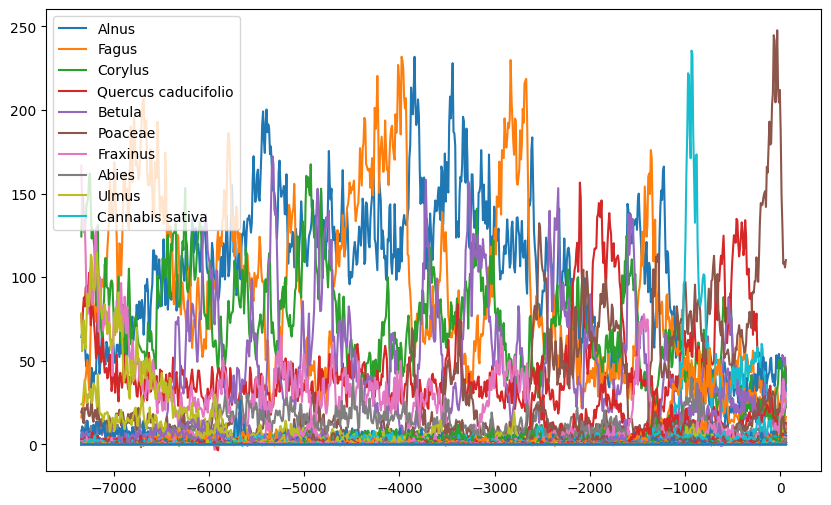

In [45]:
fig,ax = plt.subplots(figsize=(10, 6))
for spec in myspecies:
    ax.plot(species[spec]['x'], species[spec]['y'], label=spec)
# show the legend only for the first 10 species

handles, labels = ax.get_legend_handles_labels()

# 3. Slice them to only show the first 3 lines in the legend
ax.legend(handles[:10], labels[:10], loc='upper left')

<Axes: xlabel='cal BP'>

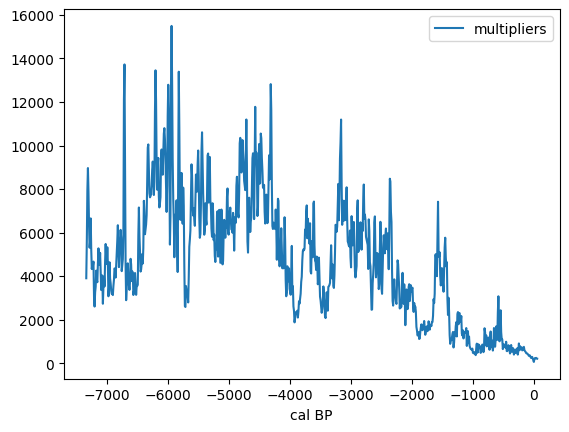

In [40]:
gam_multipliers_df.plot(x='cal BP', y='multipliers')

In [48]:
# GET TIME WINDOW CUTS

cuts = [-6000, -3900, -1500]

indices = species_df[myspecies[0]]['x'].searchsorted(cuts)
indices

array([148, 379, 643])